In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar100

# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

print(f"Original training data shape: {x_train.shape}")
print(f"Original training labels shape: {y_train.shape}")
print(f"Original test data shape: {x_test.shape}")
print(f"Original test labels shape: {y_test.shape}")

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Original training data shape: (50000, 32, 32, 3)
Original training labels shape: (50000, 1)
Original test data shape: (10000, 32, 32, 3)
Original test labels shape: (10000, 1)


In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers

# Normalize pixel values to be between 0 and 1
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

# One-hot encode the labels
num_classes = 100 # CIFAR-100 has 100 classes
y_train_one_hot = to_categorical(y_train, num_classes)
y_test_one_hot = to_categorical(y_test, num_classes)

# Split the training data into training and validation sets (80% train, 20% validation)
x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train_normalized, y_train_one_hot, test_size=0.2, random_state=42
)

# Define data augmentation layers
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomCrop(32, 32)
])

print(f"Normalized training data shape: {x_train_normalized.shape}")
print(f"One-hot encoded training labels shape: {y_train_one_hot.shape}")
print(f"Training split data shape: {x_train_split.shape}")
print(f"Validation split data shape: {x_val_split.shape}")
print(f"Training split labels shape: {y_train_split.shape}")
print(f"Validation split labels shape: {y_val_split.shape}")
print(f"Normalized test data shape: {x_test_normalized.shape}")
print(f"One-hot encoded test labels shape: {y_test_one_hot.shape}")


Normalized training data shape: (50000, 32, 32, 3)
One-hot encoded training labels shape: (50000, 100)
Training split data shape: (40000, 32, 32, 3)
Validation split data shape: (10000, 32, 32, 3)
Training split labels shape: (40000, 100)
Validation split labels shape: (10000, 100)
Normalized test data shape: (10000, 32, 32, 3)
One-hot encoded test labels shape: (10000, 100)


In [3]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l2

def create_custom_cnn(input_shape, num_classes, data_augmentation_layers):
    input_tensor = Input(shape=input_shape)

    # Apply data augmentation as the first layers of the model
    x = data_augmentation_layers(input_tensor)

    # Convolutional Block 1
    x = Conv2D(filters=32, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters=32, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)

    # Convolutional Block 2
    x = Conv2D(filters=64, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters=64, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)

    # Convolutional Block 3
    x = Conv2D(filters=128, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters=128, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)

    # Flattening and Dense layers
    x = Flatten()(x)
    x = Dense(512, kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.5)(x)

    output_tensor = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=output_tensor)
    return model

# Define input shape
input_shape = x_train_normalized.shape[1:]

# Create the custom CNN model
model = create_custom_cnn(input_shape, num_classes, data_augmentation)

# Display the model summary
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,391,236 (5.31 MB)

 Trainable params: 1,389,316 (5.30 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [4]:
from tensorflow.keras.optimizers import Adam

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(x_train_split, y_train_split,
                    epochs=50,
                    batch_size=64,
                    validation_data=(x_val_split, y_val_split))

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.0648 - loss: 5.5331 - val_accuracy: 0.1705 - val_loss: 4.3432
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.1633 - loss: 4.2955 - val_accuracy: 0.1581 - val_loss: 4.2166
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.2128 - loss: 3.8710 - val_accuracy: 0.2413 - val_loss: 3.7107
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.2461 - loss: 3.6637 - val_accuracy: 0.2424 - val_loss: 3.7818
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.2706 - loss: 3.5594 - val_accuracy: 0.2745 - val_loss: 3.6343
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.2915 - loss: 3.4674 - val_accuracy: 0.3184 - val_loss: 3.3678
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.3131 - loss: 3.4016 - val_accuracy: 0.3758 - val_loss: 3.1327
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.3254 - loss: 3.3682 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step

Evaluating model performance on the test set...
Test Loss: 3.0138
Test Accuracy: 0.4520

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.70      0.74       100
           1       0.64      0.56      0.60       100
           2       0.38      0.17      0.23       100
           3       0.24      0.10      0.14       100
           4       0.21      0.27      0.23       100
           5       0.49      0.35      0.41       100
           6       0.51      0.59      0.55       100
           7       0.68      0.41      0.51       100
           8       0.76      0.53      0.62       100
           9       0.52      0.48      0.50       100
          10       0.44      0.16      0.24       100
          11       0.37      0.14      0.20       100
          12       0.52      0.49      0.51       100
          13       0.47      0.21      0.29       100
          14       0.44      0.38  

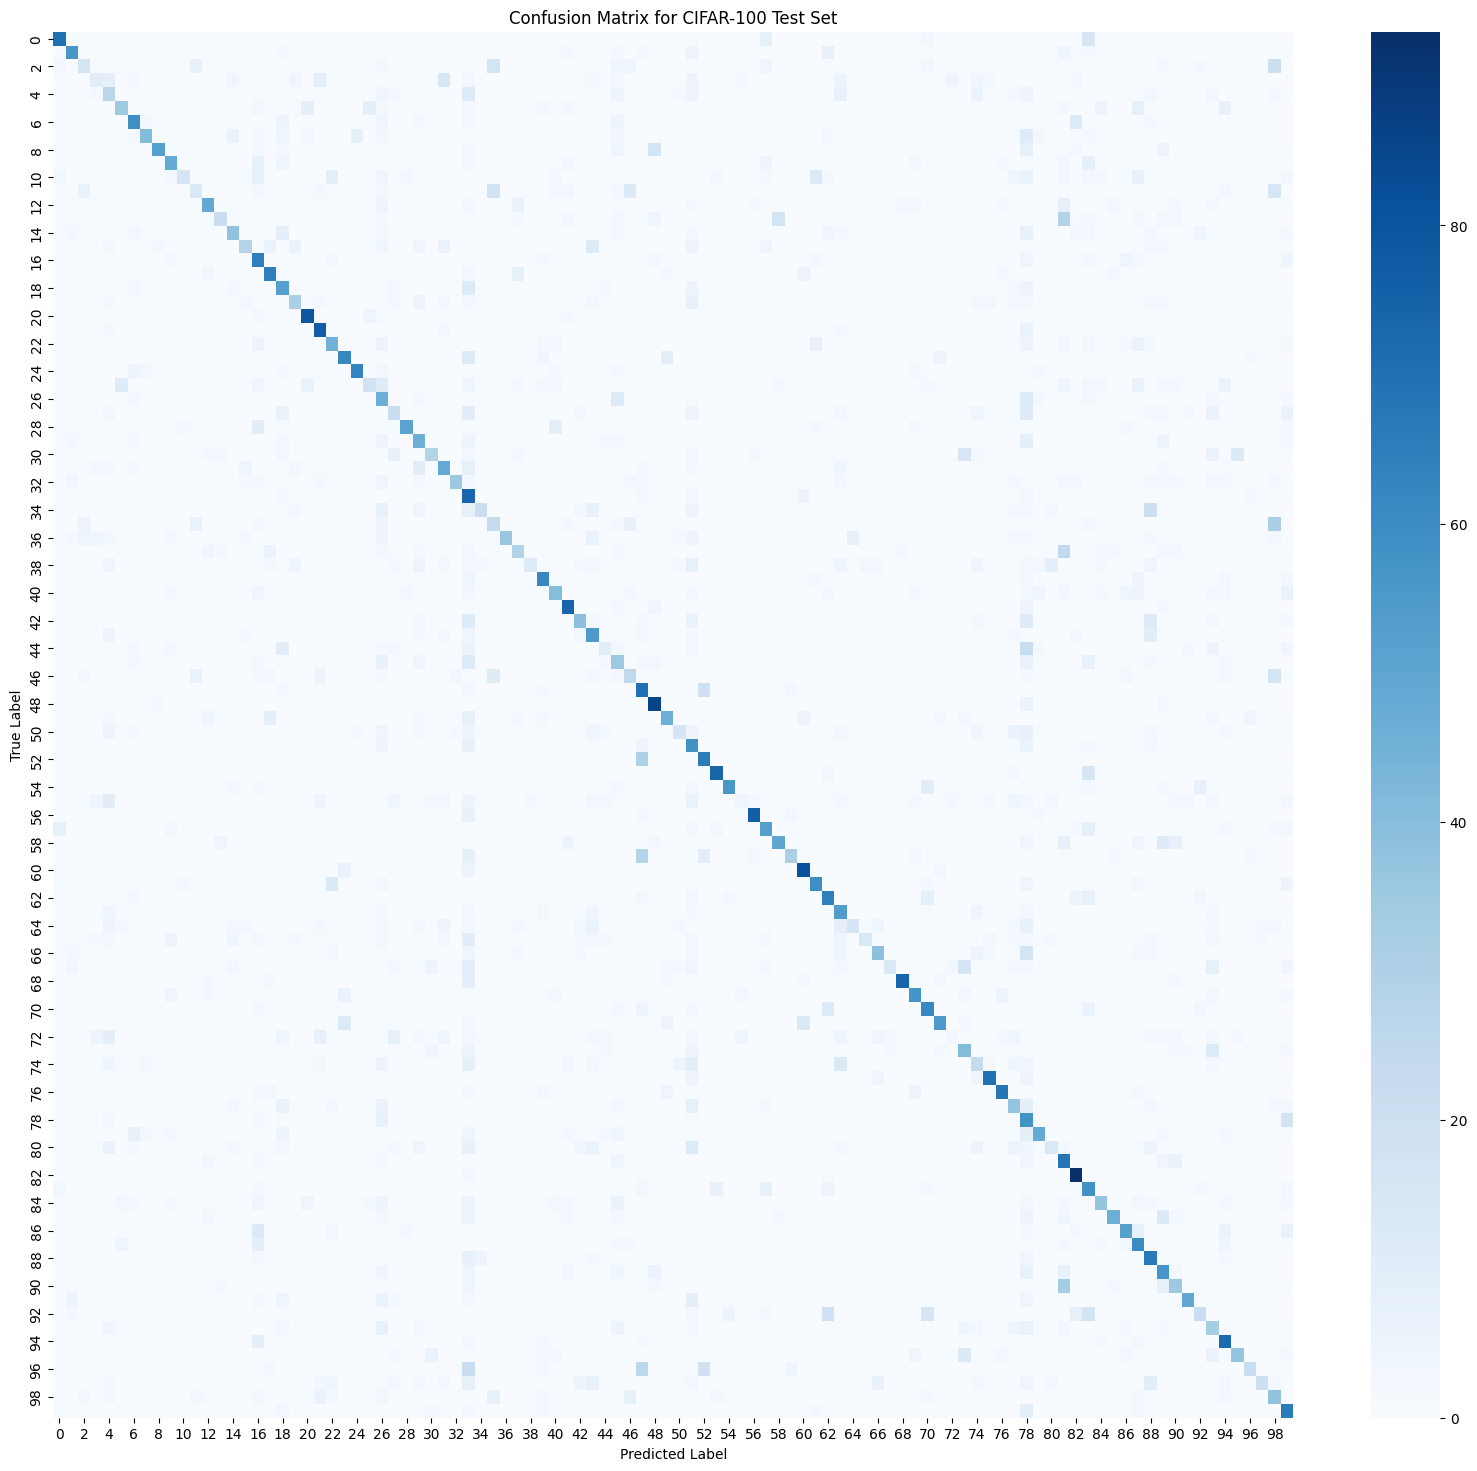

In [5]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Make predictions on the normalized test data
y_pred_probs = model.predict(x_test_normalized)

# 2. Convert predicted probabilities and true one-hot encoded labels to integer class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_one_hot, axis=1)

# 3. Evaluate the model's overall performance on the test set
print("\nEvaluating model performance on the test set...")
test_loss, test_accuracy = model.evaluate(x_test_normalized, y_test_one_hot, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# 4. Generate a classification report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=[str(i) for i in range(num_classes)]))

# 5. Compute the confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# 6. Visualize the confusion matrix as a heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(conf_matrix, annot=False, cmap='Blues', fmt='g')
plt.title('Confusion Matrix for CIFAR-100 Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

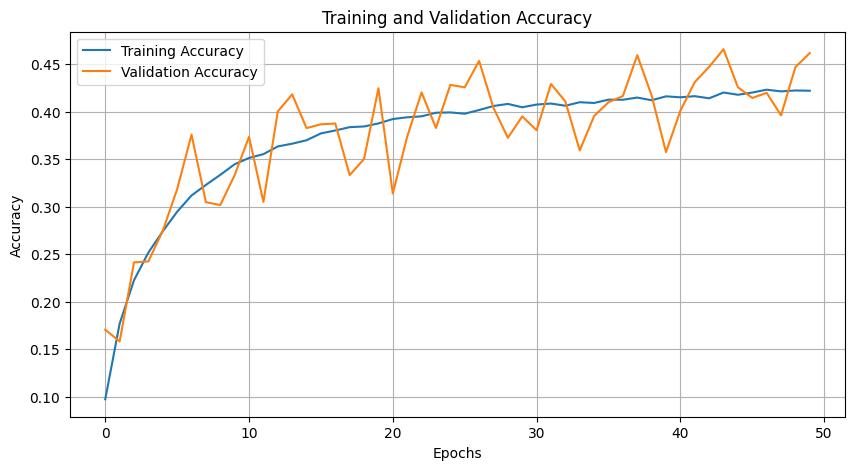

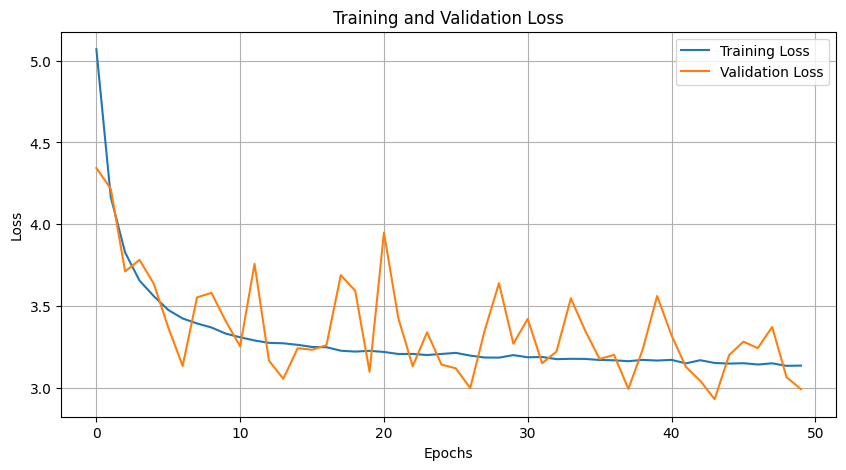

In [6]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l2

def create_vgg16_model(input_shape, num_classes):
    input_tensor = Input(shape=input_shape)

    # Block 1
    x = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0005))(input_tensor)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), strides=(2, 2))(x)

    # Block 2
    x = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), strides=(2, 2))(x)

    # Block 3
    x = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), strides=(2, 2))(x)

    # Block 4
    x = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), strides=(2, 2))(x)

    # Block 5 (optional, as CIFAR-100 images are small, but included for VGG-16 full structure)
    x = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), strides=(2, 2))(x)

    # Flattening and Dense layers
    x = Flatten()(x)
    x = Dense(4096, activation='relu', kernel_regularizer=l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(4096, activation='relu', kernel_regularizer=l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    output_tensor = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=output_tensor)
    return model

# Define input shape (from previous steps)
input_shape = x_train_normalized.shape[1:]

# Create the VGG-16 model for CIFAR-100
vgg16_model = create_vgg16_model(input_shape, num_classes)

# Display the model summary
vgg16_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,80

 Total params: 34,056,612 (129.92 MB)

 Trainable params: 34,031,780 (129.82 MB)

 Non-trainable params: 24,832 (97.00 KB)

In [8]:
from tensorflow.keras.optimizers import Adam

# Compile the VGG-16 model
vgg16_model.compile(optimizer=Adam(learning_rate=0.0001), # Often VGG models use smaller learning rates
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# Train the VGG-16 model
vgg16_history = vgg16_model.fit(x_train_split, y_train_split,
                                epochs=50, # Use the same number of epochs as the custom CNN for comparison
                                batch_size=64,
                                validation_data=(x_val_split, y_val_split))

print("VGG-16 model training complete.")

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 87s 93ms/step - accuracy: 0.0443 - loss: 9.8957 - val_accuracy: 0.1292 - val_loss: 8.3824
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.1275 - loss: 8.5197 - val_accuracy: 0.2077 - val_loss: 7.7999
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.1936 - loss: 7.8949 - val_accuracy: 0.2384 - val_loss: 7.4094
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.2533 - loss: 7.3773 - val_accuracy: 0.2939 - val_loss: 6.7973
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.3072 - loss: 6.9349 - val_accuracy: 0.3021 - val_loss: 7.3618
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.3556 - loss: 6.4786 - val_accuracy: 0.3477 - val_loss: 6.2569
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.4206 - loss: 5.9471 - val_accuracy: 0.3486 - val_loss: 6.0744
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.4814 - loss: 5.5246 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step

Evaluating VGG-16 model performance on the test set...
VGG-16 Test Loss: 5.7833
VGG-16 Test Accuracy: 0.4033

Classification Report for VGG-16:
              precision    recall  f1-score   support

           0       0.52      0.77      0.62       100
           1       0.55      0.48      0.51       100
           2       0.14      0.54      0.22       100
           3       0.34      0.13      0.19       100
           4       0.29      0.16      0.21       100
           5       0.33      0.45      0.38       100
           6       0.50      0.39      0.44       100
           7       0.39      0.62      0.48       100
           8       0.64      0.53      0.58       100
           9       0.76      0.47      0.58       100
          10       0.22      0.37      0.27       100
          11       0.32      0.20      0.25       100
          12       0.33      0.59      0.42       100
          13       0.51      0.32      0.39       100
 

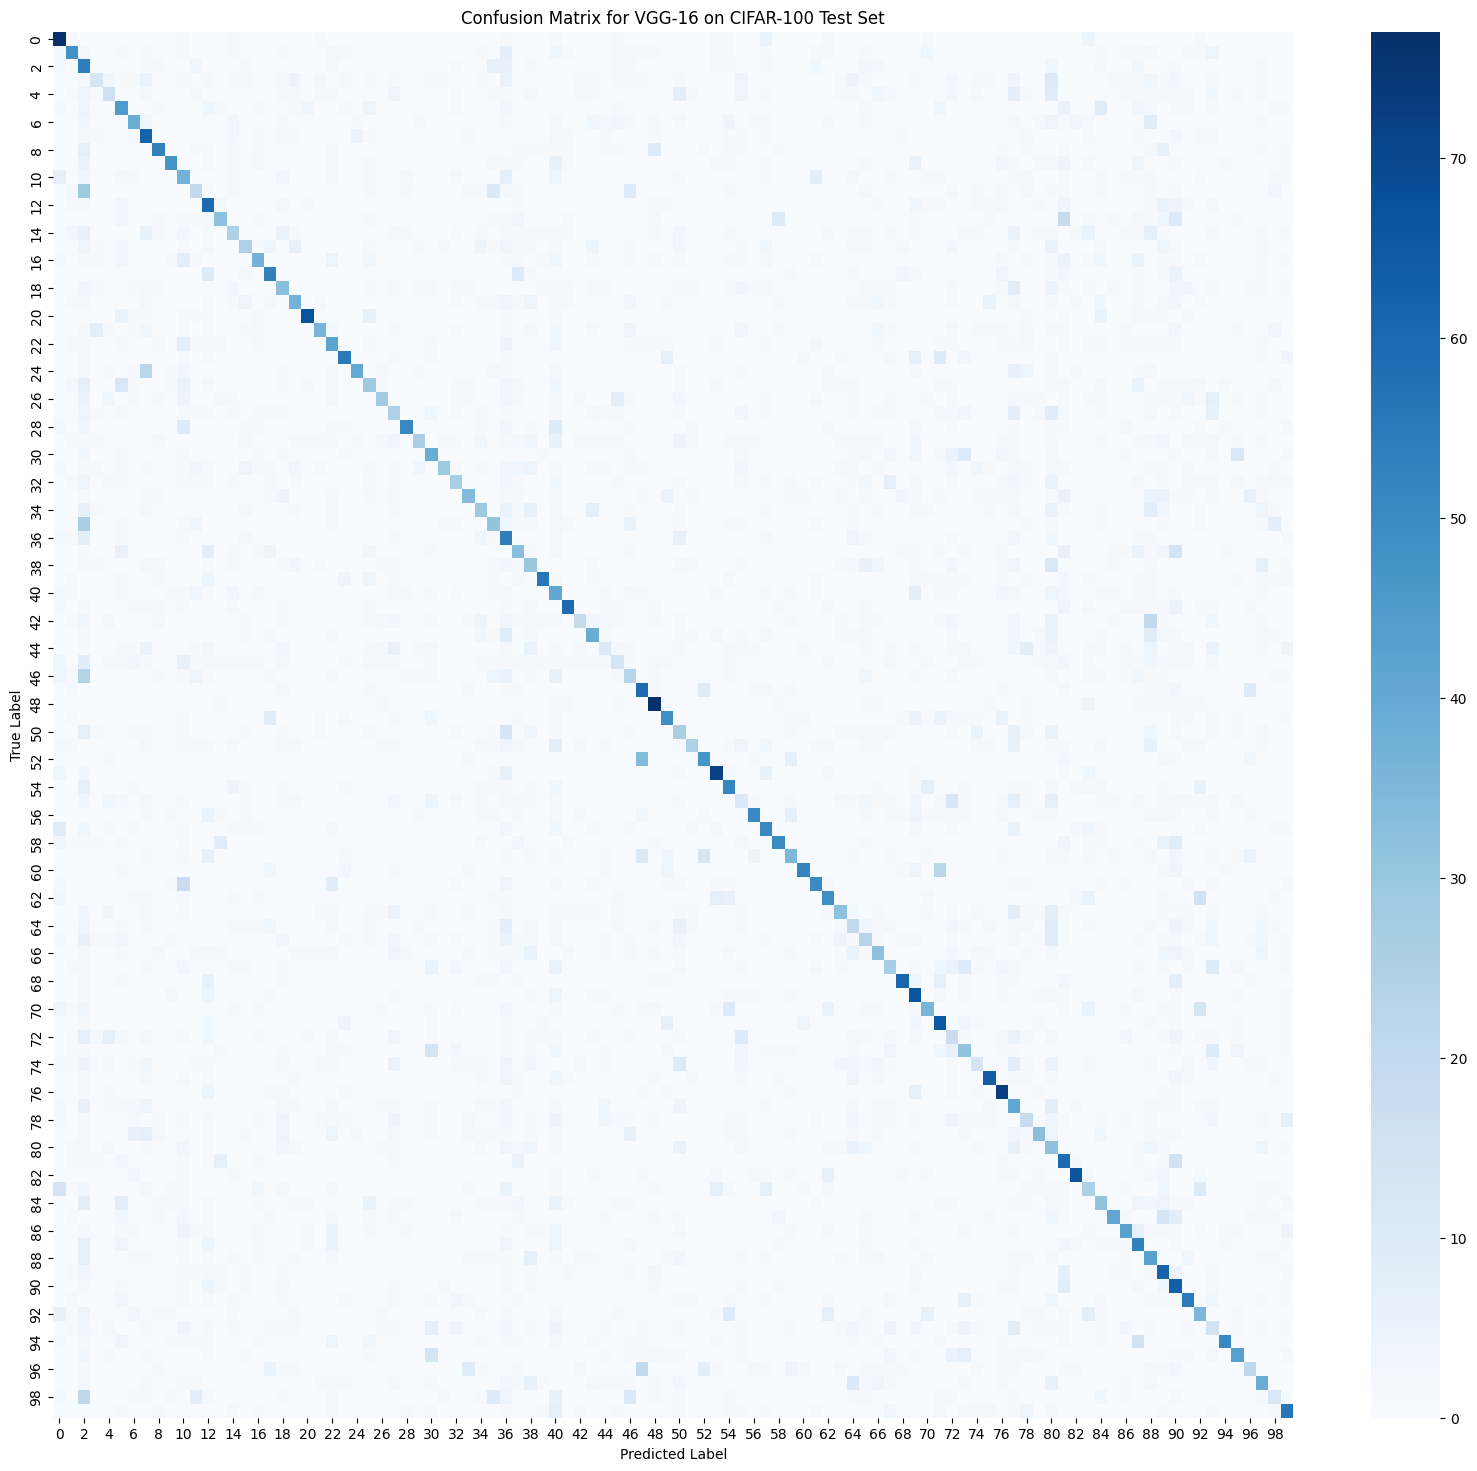

In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Make predictions on the normalized test data using the vgg16_model
y_pred_probs_vgg16 = vgg16_model.predict(x_test_normalized)

# 2. Convert predicted probabilities and true one-hot encoded labels to integer class labels
y_pred_classes_vgg16 = np.argmax(y_pred_probs_vgg16, axis=1)
y_true_classes = np.argmax(y_test_one_hot, axis=1) # y_true_classes is already available from previous evaluation, but re-assigning for clarity

# 3. Evaluate the vgg16_model's overall performance on the test set
print("\nEvaluating VGG-16 model performance on the test set...")
test_loss_vgg16, test_accuracy_vgg16 = vgg16_model.evaluate(x_test_normalized, y_test_one_hot, verbose=0)
print(f"VGG-16 Test Loss: {test_loss_vgg16:.4f}")
print(f"VGG-16 Test Accuracy: {test_accuracy_vgg16:.4f}")

# 4. Generate a classification report for VGG-16
print("\nClassification Report for VGG-16:")
print(classification_report(y_true_classes, y_pred_classes_vgg16, target_names=[str(i) for i in range(num_classes)]))

# 5. Compute the confusion matrix for VGG-16
conf_matrix_vgg16 = confusion_matrix(y_true_classes, y_pred_classes_vgg16)

# 6. Visualize the confusion matrix as a heatmap for VGG-16
plt.figure(figsize=(20, 18))
sns.heatmap(conf_matrix_vgg16, annot=False, cmap='Blues', fmt='g')
plt.title('Confusion Matrix for VGG-16 on CIFAR-100 Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

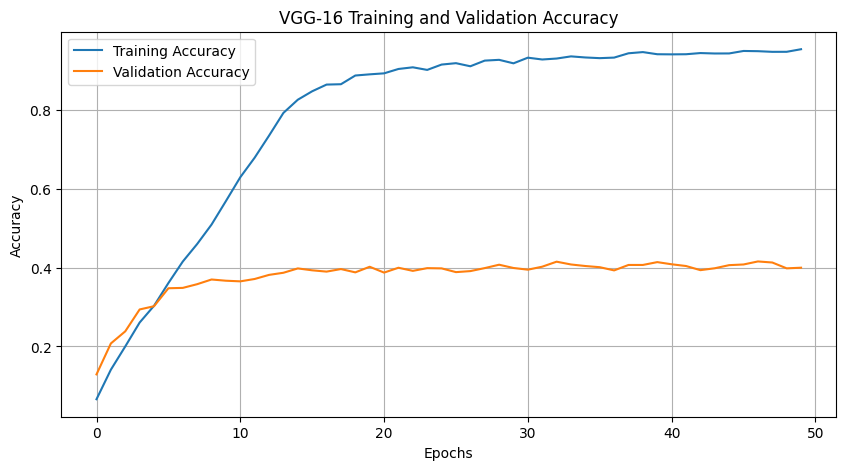

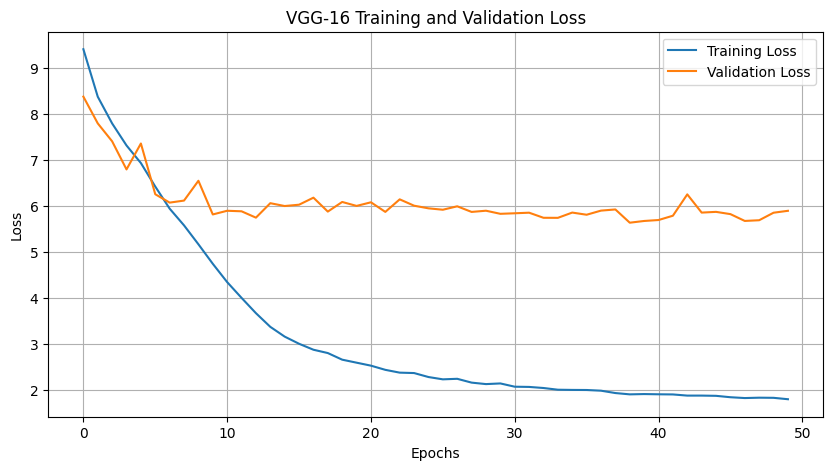

In [10]:
import matplotlib.pyplot as plt

# Plot VGG-16 training & validation accuracy values
plt.figure(figsize=(10, 5))
plt.plot(vgg16_history.history['accuracy'], label='Training Accuracy')
plt.plot(vgg16_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG-16 Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot VGG-16 training & validation loss values
plt.figure(figsize=(10, 5))
plt.plot(vgg16_history.history['loss'], label='Training Loss')
plt.plot(vgg16_history.history['val_loss'], label='Validation Loss')
plt.title('VGG-16 Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
